[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HannahPinson/tue-deeplearning-2AMM10/blob/main/tutorials/P5.1_rnn_classification.ipynb)

In [ ]:
import torch
import torch.nn as nn
import time
from datasets import load_dataset
from tqdm import tqdm
from torchtext.data.utils import get_tokenizer
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# P3.1 - Sequence classification: Predicting news article genres

In this tutorial, we provide an example of text classification using the AG News dataset. The dataset contains 120,000 datapoints for training and 7,600 datapoints for testing. Each datapoint consists of an input news article (given as a sequence of words, $X=\{x_{0:n}\}$) and a label ($Y$) indicating the article's genre. The dataset contains four genres: world, sports, business, and sci/tech. Our goal is to train a model that predicts the genre of an input news article.

### Loading the dataset

We load the AG News dataset using the Hugging Face `datasets` library, a widely used interface for accessing machine learning datasets (for an introduction, see `P3.1_hugginface_intro.ipynb`). Each example consists of a text field ($X$) containing the news article and a label ($Y$) indicating its genre. Here we load the training and test splits and print a few examples.

In [45]:
dataset = load_dataset("ag_news")

train_data = list(zip(dataset["train"]["label"], dataset["train"]["text"]))
test_data = list(zip(dataset["test"]["label"], dataset["test"]["text"]))

print(f"Number of training news articles: {len(train_data)}")
print(f"Number of testing news articles: {len(test_data)}\n")

classdict = {
    0: "world",
    1: "sports",
    2: "business",
    3: "sci/tech",
}

for i in range(3):
    y, x = test_data[i]
    print("X:", x)
    print("Y:", classdict[y], "\n")

Number of training news articles: 120000
Number of testing news articles: 7600

X: Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
Y: business 

X: The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.
Y: sci/tech 

X: Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.
Y: sci/tech 



# Preprocessing textual input data

### Creating a vocabulary

As we have seen in practical P1.2, word embeddings are useful for encoding words into dense vectors of real numbers. Before we can use word embeddings, we must first convert words into integer identifiers.

To this end, we tokenize each article, i.e., transform the full article from a string into a sequence of individual tokens. For example, the sentence `"good morning!"` becomes `["good", "morning", "!"]`.

Note that there is a subtle difference between tokens and words. For example, `"good"` and `"morning"` are both words and tokens, whereas `"!"` is a token but not a word.

After tokenizing all training articles, we construct a vocabulary by assigning a unique integer index to each distinct token. We also include a special `<unk>` token, which is used for tokens that appear later but were not present in the training vocabulary.

In [46]:
tokenizer = get_tokenizer("basic_english")

vocab = {"<unk>": 0}

for _, article in tqdm(train_data):
    for token in tokenizer(article):
        if token not in vocab:
            vocab[token] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
print(f"vocab['the']={vocab['the']}")
print(f"vocab['<unk>']={vocab['<unk>']}")

100%|██████████| 120000/120000 [00:01<00:00, 79347.60it/s]

Vocabulary size: 95811
vocab['the']=8
vocab['<unk>']=0


The tokenizer converts an input sentence into a sequence of tokens. More specifically, it converts all characters to lowercase and splits the sentence into individual words and punctuation marks. For example:

    tokenizer("You can now install TorchText using pip!")
    >>> ['you', 'can', 'now', 'install', 'torchtext', 'using', 'pip', '!']

The vocabulary allows us to convert a list of tokens into integer identifiers. If a token is not part of the vocabulary, we map it to the `<unk>` index:

    tokens = ['here', 'is', 'an', 'example']
    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]

### Creating text and label pipelines

We now define two preprocessing pipelines. The `text_pipeline` tokenizes a raw text string and converts each token into its corresponding integer index using the vocabulary. Tokens that are not present in the vocabulary are mapped to the `<unk>` index.

The `label_pipeline` converts the class label into the integer format expected by the model.

In [47]:
text_pipeline = lambda x: [vocab.get(token, vocab["<unk>"]) for token in tokenizer(x)]
label_pipeline = lambda y: int(y)

In [48]:
print(text_pipeline("here is an example"))
print(label_pipeline(2))

[880, 180, 93, 2522]
2


### Creating batch iterators

We use `torch.utils.data.DataLoader` to create an input pipeline that processes both the textual input data and labels, making them compatible with a PyTorch model. Additionally, the `DataLoader` provides useful functionality such as batching, shuffling, and parallel data loading.

We specify how individual datapoints should be combined into a batch using the `collate_fn` function, which can be passed as an argument to the `DataLoader`. The input to `collate_fn` is a list of $k$ datapoints, where $k$ denotes the batch size. The function then processes each datapoint using the vocabulary, text pipeline, and label pipeline defined previously.

Note that the number of words in each article is not necessarily the same. This often causes difficulties when batching multiple datapoints together. To solve this issue, we zero-pad the sequences, i.e., append zeros such that all sequences within a batch have the same length. We additionally keep track of the original sequence lengths before padding.

**Tip:** Ideally, we do not want these padded tokens to be processed by the RNN, since they do not contain meaningful information. PyTorch provides functionality for converting padded sequences into a more memory- and computationally-efficient representation by packing them. By combining the padded sequences with their original lengths, the RNN can ignore the padded positions and process only the valid tokens of each sequence.

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def collate_batch(batch):
    label_list, text_list, length_list = [], [], []

    for label, text in batch:
        processed_text = torch.tensor(text_pipeline(text), dtype=torch.int64)

        label_list.append(label_pipeline(label))
        text_list.append(processed_text)
        length_list.append(processed_text.size(0))

    label_batch = torch.tensor(label_list, dtype=torch.int64)
    length_batch = torch.tensor(length_list, dtype=torch.int64)

    padded_text_batch = pad_sequence(
        text_list,
        batch_first=True,
        padding_value=0,
    )

    return (
        label_batch.to(device),
        padded_text_batch.to(device),
        length_batch.to(device),
    )


dataloader = DataLoader(
    train_data,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_batch,
)

In [50]:
labels, padded_batch, length_batch = next(iter(dataloader))
print(labels)
print(padded_batch.shape)
print(length_batch)

tensor([2, 0, 0, 1, 1, 1, 2, 0])
torch.Size([8, 61])
tensor([42, 54, 44, 44, 37, 50, 61, 31])


It is often useful to have access to a single batch of data. For instance, during model development we may want to feed a single batch to our model and verify that the code runs without errors. We can extract a single batch from the `DataLoader` as follows:

    >>> y_batch, x_batch = next(iter(dataloader))

Furthermore, we can iterate over the entire dataset in batches using the `DataLoader`, i.e.

    >>> for batch_idx, (y_batch, x_batch) in enumerate(dataloader):
            pass

# Define, train and evaluate the recurrent classification model

We employ a recurrent neural network (RNN) that processes the words of each news article sequentially. The first layer is an embedding layer that maps each token index to a dense vector with `embed_dim=500` entries. The next layer is an RNN layer with 128 hidden units. By default, PyTorch initializes the hidden state with zeros and updates it after processing the embedding of each token in the sequence.

If trained properly, the hidden state at the final timestep, i.e. after all tokens in an article have been processed, contains information that can be used to predict the article's genre. Finally, two dense layers with a ReLU nonlinearity in between map this final hidden state to a vector of length `num_class=4`.

The predicted class is obtained using `torch.argmax`. Alternatively, one could apply a softmax activation function after the final dense layer to obtain class probabilities, and then select the class with the highest probability.

In [51]:
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence


class RNNClassificationModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, n_layers, hidden_dim, num_class):
        super(RNNClassificationModel, self).__init__()

        self.word_embeddings = nn.Embedding(vocab_size, embed_dim)

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
        )

        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_class)

        self.drop = nn.Dropout(p=0.5)

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.parameters())

    def forward(self, text, lengths):

        # text: [batch_size, max_sequence_length]
        # lengths: [batch_size]

        h = self.word_embeddings(text)

        packed_h = pack_padded_sequence(
            h,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, hidden = self.rnn(packed_h)

        # hidden: [n_layers, batch_size, hidden_dim]
        last_hidden = hidden[-1]

        last_hidden = self.drop(last_hidden)

        h = self.fc1(last_hidden)
        h = nn.ReLU()(h)
        h = self.drop(h)

        y_pred = self.fc2(h)

        return y_pred

In [52]:
def train(model, dataloader):
    model.train()

    total_correct = 0
    total_samples = 0

    for y_true, text_batch, lengths in tqdm(dataloader):
        model.optimizer.zero_grad()

        logits = model(text_batch, lengths)
        loss = model.criterion(logits, y_true)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        model.optimizer.step()

        predictions = logits.argmax(dim=-1)

        total_correct += (predictions == y_true).sum().item()
        total_samples += y_true.size(0)

    return total_correct / total_samples


def evaluate(model, dataloader):
    model.eval()

    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for y_true, text_batch, lengths in dataloader:
            logits = model(text_batch, lengths)
            predictions = logits.argmax(dim=-1)

            total_correct += (predictions == y_true).sum().item()
            total_samples += y_true.size(0)

    return total_correct / total_samples

### Combine everything, train and evaluate model

In [53]:
# hyperparameters
EPOCHS = 10
BATCH_SIZE = 256

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

model = RNNClassificationModel(
    vocab_size=len(vocab),
    embed_dim=500,
    n_layers=1,
    hidden_dim=128,
    num_class=4,
).to(device)

train_acc, val_acc = [], []

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    train_acc.append(train(model, train_dataloader))
    val_acc.append(evaluate(model, test_dataloader))

    print("-" * 59)
    print(
        f"| end of epoch {epoch:3d} | "
        f"time: {time.time() - epoch_start_time:5.2f}s | "
        f"train accuracy {train_acc[-1]:8.3f} | "
        f"valid accuracy {val_acc[-1]:8.3f} |"
    )
    print("-" * 59)

100%|██████████| 469/469 [00:45<00:00, 10.33it/s]


-----------------------------------------------------------
| end of epoch   1 | time: 45.86s | train accuracy    0.533 | valid accuracy    0.688 |
-----------------------------------------------------------


100%|██████████| 469/469 [00:48<00:00,  9.58it/s]


-----------------------------------------------------------
| end of epoch   2 | time: 49.41s | train accuracy    0.771 | valid accuracy    0.826 |
-----------------------------------------------------------


100%|██████████| 469/469 [00:50<00:00,  9.32it/s]


...

-----------------------------------------------------------
| end of epoch   8 | time: 65.04s | train accuracy    0.926 | valid accuracy    0.877 |
-----------------------------------------------------------


100%|██████████| 469/469 [01:01<00:00,  7.62it/s]


-----------------------------------------------------------
| end of epoch   9 | time: 62.20s | train accuracy    0.930 | valid accuracy    0.878 |
-----------------------------------------------------------


100%|██████████| 469/469 [01:06<00:00,  7.09it/s]


-----------------------------------------------------------
| end of epoch  10 | time: 66.83s | train accuracy    0.937 | valid accuracy    0.879 |
-----------------------------------------------------------


Text(0, 0.5, 'Accuracy')

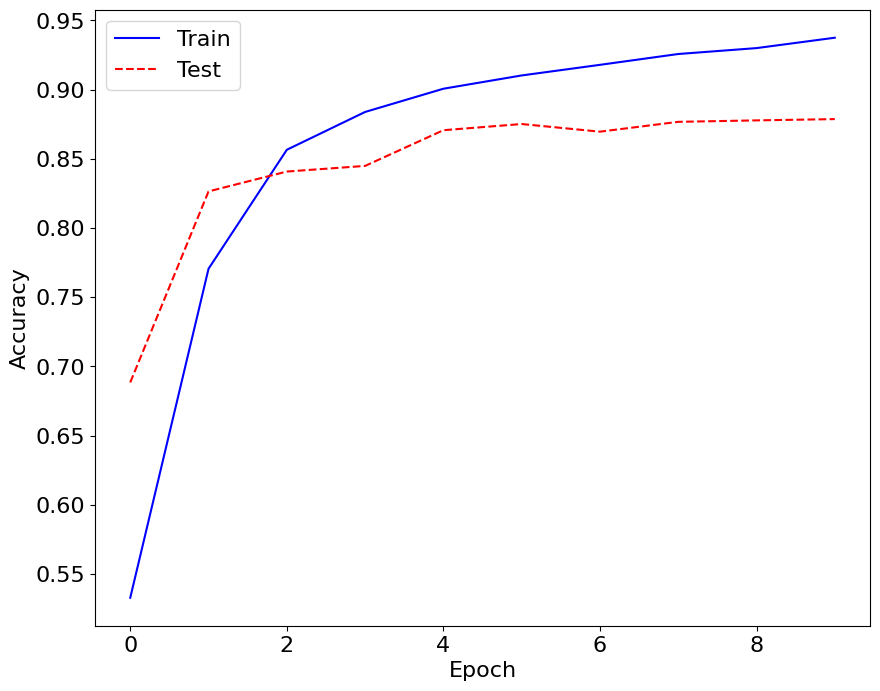

In [54]:
f, ax = plt.subplots(1, 1, figsize=(10, 8))

fnt = 16
ax.plot(train_acc, color="blue", label="Train")
ax.plot(val_acc, color="red", linestyle="--", label="Test")
ax.legend(fontsize=fnt)
ax.tick_params(axis="both", labelsize=fnt)

ax.set_xlabel("Epoch", fontsize=fnt)
ax.set_ylabel("Accuracy", fontsize=fnt)

### Confusion matrix

For classification tasks, it is often instructive to inspect the confusion matrix. The confusion matrix shows how often examples from each true class are predicted as each possible class. This makes it easier to identify which classes are frequently confused by the model.

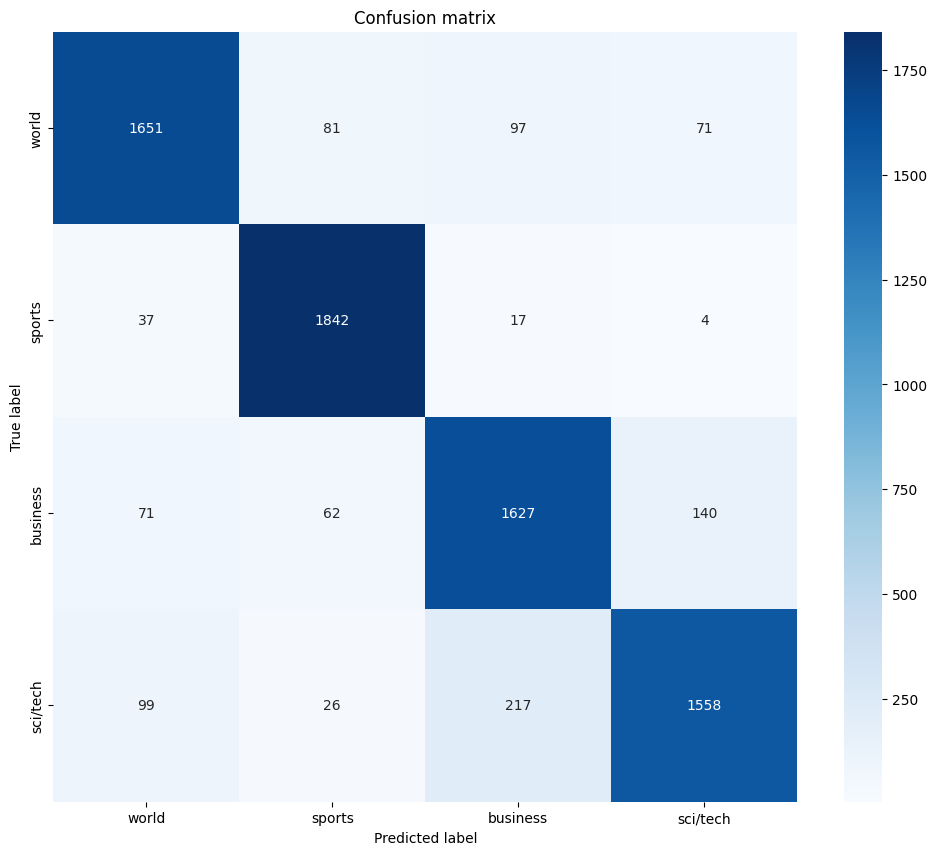

In [60]:
test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for y, text_batch, lengths in test_dataloader:
        logits = model(text_batch, lengths)

        y_pred.append(logits.argmax(dim=1))
        y_true.append(y)

y_true_np = torch.cat(y_true).cpu().numpy()
y_pred_np = torch.cat(y_pred).cpu().numpy()

cm = confusion_matrix(y_true_np, y_pred_np)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    ax=ax,
    cmap="Blues",
    fmt="d",
    xticklabels=classdict.values(),
    yticklabels=classdict.values(),
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix")
plt.show()